# Credit Card Default – Tariff Table & Business Recommendation
### ตารางอัตราดอกเบี้ยตามความเสี่ยง และข้อเสนอแนะทางธุรกิจ

**English**
- **What this notebook does:** turns the model from `03_modeling.ipynb` into business decisions. Every customer gets a **risk grade (A–E)**. Each grade gets a **tariff**: an interest rate and a credit-limit action. It ends with **recommendations** for the bank.
- **Input:** `data/default_clean.csv`. SQL queries: `sql/04_tariff.sql`.
- **Outputs:**
  - `outputs/tariff_table.csv` – the tariff table (opens in Excel)
  - `outputs/figures/12_…` to `14_…` – 3 charts
- **Read it in 3 minutes:** skip the code. Read **Section 4 (tariff table)**, the 3 charts with their **How to read** notes, and **Section 6 (recommendations)**.

**ภาษาไทย**
- **Notebook นี้ทำอะไร:** นำโมเดลจาก `03_modeling.ipynb` มาใช้ตัดสินใจทางธุรกิจ ลูกค้าทุกคนจะได้ **เกรดความเสี่ยง (A–E)** แต่ละเกรดมี **ตารางเงื่อนไข (tariff)** คืออัตราดอกเบี้ยและการจัดการวงเงิน ปิดท้ายด้วย **ข้อเสนอแนะ** สำหรับธนาคาร
- **ข้อมูลเข้า:** `data/default_clean.csv` คำสั่ง SQL อยู่ใน `sql/04_tariff.sql`
- **ผลลัพธ์:**
  - `outputs/tariff_table.csv` – ตาราง tariff (เปิดด้วย Excel ได้)
  - `outputs/figures/12_…` ถึง `14_…` – กราฟ 3 รูป
- **อ่านจบใน 3 นาที:** ข้ามโค้ดได้เลย อ่าน **หัวข้อ 4 (ตาราง tariff)** ดูกราฟ 3 รูปพร้อม **วิธีอ่าน** และอ่าน **หัวข้อ 6 (ข้อเสนอแนะ)**

| Figure / กราฟ | Shows / แสดงอะไร |
|---|---|
| `12_customers_vs_expected_loss.png` | Share of customers vs share of expected loss per grade / สัดส่วนลูกค้าเทียบกับสัดส่วนความเสียหายในแต่ละเกรด |
| `13_required_rate_vs_cap.png` | Interest rate each grade needs vs the legal cap / ดอกเบี้ยที่แต่ละเกรดต้องเก็บ เทียบกับเพดานดอกเบี้ย |
| `14_balance_grade_card.png` | Which grade a balance falls into / ยอดหนี้เท่านี้อยู่เกรดไหน |

## 0. Setup – code only, you can skip / ส่วนตั้งค่า เป็นโค้ด ข้ามได้

In [12]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import Markdown, display
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from sql_utils import load_queries

ROOT = Path.cwd()
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42

df = pd.read_csv(ROOT / "data" / "default_clean.csv")
con = duckdb.connect()
queries = load_queries(ROOT / "sql" / "04_tariff.sql")


def run(name, **params):
    """Show the named query from sql/04_tariff.sql, then return its result."""
    note = f"\n\nParameters: `{params}`" if params else ""
    display(Markdown(f"```sql\n{queries[name]}\n```{note}"))
    return (con.execute(queries[name], params) if params else con.execute(queries[name])).df()


sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", None)
GRADE_COLORS = {"A": "#2E7D32", "B": "#9CCC65", "C": "#FFD54F", "D": "#FB8C00", "E": "#C62828"}

## 1. Business assumptions / สมมติฐานทางธุรกิจ

The data has no interest rates or costs, so the money numbers use **example assumptions**. Change them in the next cell to test other scenarios. We also treat the model's chance of default as a **1-year** chance.

ข้อมูลไม่มีอัตราดอกเบี้ยหรือต้นทุน ตัวเลขทางการเงินจึงใช้ **สมมติฐานตัวอย่าง** แก้ได้ในเซลล์ถัดไปเพื่อทดลองสถานการณ์อื่น และถือว่าโอกาสผิดนัดจากโมเดลเป็นโอกาส **ภายใน 1 ปี**

| Name | Meaning | ความหมาย |
|---|---|---|
| `lgd` | Share of the balance lost when a customer defaults | สัดส่วนของยอดหนี้ที่เสียไปเมื่อลูกค้าผิดนัด |
| `cost_of_funds` | Bank's cost of money, per year | ต้นทุนเงินทุนของธนาคาร ต่อปี |
| `operating_cost` | Cost to run the account, per year | ต้นทุนดูแลบัญชี ต่อปี |
| `target_margin` | Profit the bank wants, per year | กำไรที่ธนาคารต้องการ ต่อปี |
| `rate_cap` | Highest interest the bank may charge (Thailand's credit-card cap is 16% per year) | ดอกเบี้ยสูงสุดที่เก็บได้ (เพดานบัตรเครดิตในไทยคือ 16% ต่อปี) |

In [16]:
ASSUMPTIONS = {
    "lgd": 0.80,
    "cost_of_funds": 0.03,
    "operating_cost": 0.04,
    "target_margin": 0.03,
    "rate_cap": 0.16,
}
pd.Series(ASSUMPTIONS).mul(100).rename("value (%)").to_frame()

,value (%)
lgd,80.0
cost_of_funds,3.0
operating_cost,4.0
target_margin,3.0
rate_cap,16.0


## 2. Score customers and give each a risk grade / ให้คะแนนและเกรดความเสี่ยงลูกค้า

**EN:** we use the same model as notebook 03 (logistic regression with `balance` + `is_student`, trained on the same 7,000 customers). We score the **3,000 test customers the model has never seen**, so the results are honest.

**TH:** ใช้โมเดลเดียวกับ notebook 03 (logistic regression ใช้ `balance` + `is_student` ฝึกด้วยลูกค้า 7,000 คนชุดเดิม) แล้วให้คะแนนลูกค้า **3,000 คนที่โมเดลไม่เคยเห็น** ผลลัพธ์จึงเชื่อถือได้

In [17]:
train, test = train_test_split(df, test_size=0.3, stratify=df["default_flag"], random_state=SEED)
model = smf.logit("default_flag ~ balance + is_student", data=train).fit(disp=0)

scored = test[["customer_id", "default_flag", "balance", "is_student"]].assign(
    prob_default=model.predict(test).to_numpy()
)
con.register("scored", scored)
auc = roc_auc_score(scored["default_flag"], scored["prob_default"])
print(f"Scored {len(scored):,} test customers. Test AUC = {auc:.3f} (same as notebook 03)")

Scored 3,000 test customers. Test AUC = 0.951 (same as notebook 03)


**Risk grades / เกรดความเสี่ยง:** grades C, D, E match the Medium / High / Very high bands in notebook 03. The low-risk group is split into A and B so the bank can reward its safest customers.

เกรด C, D, E ตรงกับกลุ่ม Medium / High / Very high ใน notebook 03 ส่วนกลุ่มเสี่ยงต่ำแบ่งเป็น A และ B เพื่อให้ธนาคารให้สิทธิพิเศษกับลูกค้าที่ปลอดภัยที่สุดได้

In [18]:
grades = pd.DataFrame({
    "grade": ["A", "B", "C", "D", "E"],
    "label": ["Very low", "Low", "Medium", "High", "Very high"],
    "pd_range": ["< 1%", "1-5%", "5-20%", "20-50%", "50%+"],
    "pd_from": [0.00, 0.01, 0.05, 0.20, 0.50],
    "pd_to": [0.01, 0.05, 0.20, 0.50, 1.01],
})
con.register("grade_bands", grades)
grades[["grade", "label", "pd_range"]].rename(columns={"pd_range": "chance of default"})

,grade,label,chance of default
0,A,Very low,< 1%
1,B,Low,1-5%
2,C,Medium,5-20%
3,D,High,20-50%
4,E,Very high,50%+


## 3. Portfolio by grade (SQL) / ภาพรวมพอร์ตตามเกรด

- **expected_loss** = chance of default × balance × LGD (money the bank expects to lose, same unit as balance)
- **actual_loss** = what really happened in the test data
- **expected_loss** = โอกาสผิดนัด × ยอดหนี้ × LGD (เงินที่คาดว่าจะเสีย หน่วยเดียวกับยอดหนี้)
- **actual_loss** = ความเสียหายที่เกิดขึ้นจริงในข้อมูลทดสอบ

In [19]:
portfolio = run("grade_summary", lgd=ASSUMPTIONS["lgd"])
portfolio

```sql
SELECT
    g.grade,
    g.label,
    g.pd_range,
    COUNT(*)                                                    AS n_customers,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)          AS pct_of_customers,
    CAST(SUM(s.default_flag) AS INTEGER)                        AS n_default,
    ROUND(100 * AVG(s.prob_default), 2)                         AS predicted_pd_pct,
    ROUND(100 * AVG(s.default_flag), 2)                         AS actual_default_pct,
    ROUND(AVG(s.balance), 0)                                    AS avg_balance,
    ROUND($lgd * SUM(s.prob_default * s.balance), 0)            AS expected_loss,
    ROUND($lgd * SUM(s.default_flag * s.balance), 0)            AS actual_loss,
    ROUND(100.0 * SUM(s.prob_default * s.balance)
                / SUM(SUM(s.prob_default * s.balance)) OVER (), 1) AS pct_of_expected_loss
FROM scored AS s
JOIN grade_bands AS g
  ON s.prob_default >= g.pd_from AND s.prob_default < g.pd_to
GROUP BY g.grade, g.label, g.pd_range
ORDER BY g.grade;
```

Parameters: `{'lgd': 0.8}`

,grade,label,pd_range,n_customers,pct_of_customers,n_default,predicted_pd_pct,actual_default_pct,avg_balance,expected_loss,actual_loss,pct_of_expected_loss
0,A,Very low,< 1%,2156,71.9,4,0.18,0.19,594.0,2866.0,3400.0,1.9
1,B,Low,1-5%,467,15.6,10,2.36,2.14,1246.0,11346.0,9798.0,7.4
2,C,Medium,5-20%,219,7.3,24,10.52,10.96,1521.0,28616.0,29875.0,18.7
3,D,High,20-50%,108,3.6,29,31.93,26.85,1777.0,49477.0,41542.0,32.4
4,E,Very high,50%+,50,1.7,33,71.44,66.00,2095.0,60564.0,55855.0,39.6


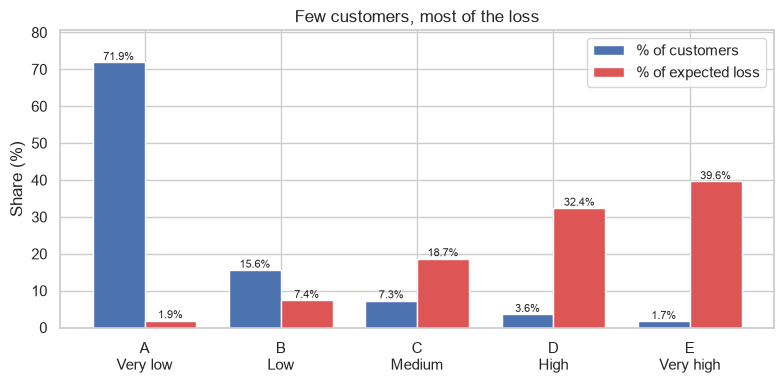

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
x, w = np.arange(len(portfolio)), 0.38
bars_c = ax.bar(x - w / 2, portfolio["pct_of_customers"], w, label="% of customers", color="#4C72B0")
bars_l = ax.bar(x + w / 2, portfolio["pct_of_expected_loss"], w, label="% of expected loss", color="#DD5555")
ax.bar_label(bars_c, fmt="%.1f%%", fontsize=8)
ax.bar_label(bars_l, fmt="%.1f%%", fontsize=8)
ax.set_xticks(x, [f"{g}\n{lbl}" for g, lbl in zip(portfolio["grade"], portfolio["label"])])
ax.set(title="Few customers, most of the loss", ylabel="Share (%)")
ax.margins(y=0.12)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "12_customers_vs_expected_loss.png", dpi=150)
plt.show()

**How to read:** for each grade, the blue bar is its share of customers, and the red bar is its share of the money the bank expects to lose.
**Look for:** grades **D + E are only 5.3% of customers but 72% of the expected loss**. Grade A is 71.9% of customers but only 1.9% of the loss.

**วิธีอ่าน:** ในแต่ละเกรด แท่งสีน้ำเงินคือสัดส่วนลูกค้า แท่งสีแดงคือสัดส่วนเงินที่ธนาคารคาดว่าจะเสีย
**สังเกต:** เกรด **D + E มีลูกค้าแค่ 5.3% แต่เป็นความเสียหายถึง 72%** ส่วนเกรด A มีลูกค้า 71.9% แต่เป็นความเสียหายแค่ 1.9%

**Can we trust the grades? / เชื่อถือเกรดได้ไหม:** yes. In the table above, predicted and actual default rates are close in every grade (e.g. C: 10.5% vs 11.0%). In D and E the model is slightly cautious (it predicts a bit more risk than really happened).
เชื่อได้ ในตารางด้านบน อัตราผิดนัดที่ทำนายกับที่เกิดจริงใกล้กันทุกเกรด (เช่น C: 10.5% เทียบกับ 11.0%) ส่วนเกรด D และ E โมเดลประเมินความเสี่ยงสูงกว่าจริงเล็กน้อย (ระมัดระวังไว้ก่อน)

## 4. Tariff table / ตารางอัตราดอกเบี้ยและเงื่อนไขตามเกรด

**EN – how the rate is set:**
- **Required rate** = cost of funds + operating cost + expected loss rate (chance of default × LGD) + target margin
- **Offered rate** = the required rate, but never above the legal cap
- **Profit rate** = offered rate − costs − expected loss rate. If it is **negative**, the bank loses money on that grade even at the highest legal rate, so it must manage the **credit limit** instead of the price.

**TH – วิธีตั้งอัตราดอกเบี้ย:**
- **ดอกเบี้ยที่ต้องเก็บ** = ต้นทุนเงินทุน + ต้นทุนดำเนินงาน + อัตราความเสียหายที่คาด (โอกาสผิดนัด × LGD) + กำไรเป้าหมาย
- **ดอกเบี้ยที่เสนอ** = ดอกเบี้ยที่ต้องเก็บ แต่ไม่เกินเพดาน
- **อัตรากำไร** = ดอกเบี้ยที่เสนอ − ต้นทุน − อัตราความเสียหายที่คาด ถ้า **ติดลบ** แปลว่าธนาคารขาดทุนในเกรดนั้นแม้เก็บดอกเบี้ยเต็มเพดาน จึงต้องคุม **วงเงิน** แทนการขึ้นราคา

In [21]:
ACTION_TH = {
    "Lower rate; can offer limit increase": "ลดดอกเบี้ยได้ และเสนอเพิ่มวงเงินได้",
    "Risk-based rate; keep standard limit": "ดอกเบี้ยตามความเสี่ยง คงวงเงินปกติ",
    "Charge the cap; no limit increase; monitor monthly": "เก็บดอกเบี้ยเต็มเพดาน ไม่เพิ่มวงเงิน ติดตามทุกเดือน",
    "Freeze limit; early reminder; offer payment plan": "ระงับวงเงิน แจ้งเตือนก่อนครบกำหนด เสนอแผนผ่อนชำระ",
    "Block new spending; collections or restructuring": "ระงับการใช้จ่ายใหม่ ติดตามหนี้หรือปรับโครงสร้างหนี้",
}
tariff = run("tariff_table", **ASSUMPTIONS)
tariff["action_th"] = tariff["action"].map(ACTION_TH)
# utf-8-sig so Excel shows the Thai text correctly
tariff.to_csv(ROOT / "outputs" / "tariff_table.csv", index=False, encoding="utf-8-sig")
tariff

```sql
-- Required rate = cost of funds + operating cost + expected loss rate (PD x LGD) + target margin.
-- The bank can charge at most $rate_cap, so risky grades are managed with limits, not price.
WITH by_grade AS (
    SELECT
        g.grade,
        g.label,
        g.pd_range,
        COUNT(*)            AS n_customers,
        AVG(s.prob_default) AS pd,
        SUM(s.balance)      AS total_balance
    FROM scored AS s
    JOIN grade_bands AS g
      ON s.prob_default >= g.pd_from AND s.prob_default < g.pd_to
    GROUP BY g.grade, g.label, g.pd_range
),
priced AS (
    SELECT
        *,
        pd * $lgd                                                      AS el_rate,
        $cost_of_funds + $operating_cost + pd * $lgd + $target_margin  AS required_rate
    FROM by_grade
),
capped AS (
    SELECT
        *,
        LEAST(required_rate, $rate_cap)                                AS offered_rate,
        LEAST(required_rate, $rate_cap) - $cost_of_funds - $operating_cost - el_rate AS profit_rate
    FROM priced
)
SELECT
    grade,
    label,
    pd_range,
    n_customers,
    ROUND(100 * pd, 2)                   AS predicted_pd_pct,
    ROUND(100 * el_rate, 2)              AS expected_loss_rate_pct,
    ROUND(100 * required_rate, 1)        AS required_rate_pct,
    ROUND(100 * offered_rate, 1)         AS offered_rate_pct,
    ROUND(100 * profit_rate, 1)          AS profit_rate_pct,
    ROUND(total_balance * profit_rate, 0) AS expected_profit,
    CASE
        WHEN required_rate <= $rate_cap AND pd < 0.01 THEN 'Lower rate; can offer limit increase'
        WHEN required_rate <= $rate_cap              THEN 'Risk-based rate; keep standard limit'
        WHEN profit_rate >= 0                        THEN 'Charge the cap; no limit increase; monitor monthly'
        WHEN pd < 0.50                               THEN 'Freeze limit; early reminder; offer payment plan'
        ELSE                                              'Block new spending; collections or restructuring'
    END AS action
FROM capped
ORDER BY grade;
```

Parameters: `{'lgd': 0.8, 'cost_of_funds': 0.03, 'operating_cost': 0.04, 'target_margin': 0.03, 'rate_cap': 0.16}`

,grade,label,pd_range,n_customers,predicted_pd_pct,expected_loss_rate_pct,required_rate_pct,offered_rate_pct,profit_rate_pct,expected_profit,action,action_th
0,A,Very low,< 1%,2156,0.18,0.14,10.1,10.1,3.0,38403.0,Lower rate; can offer limit increase,ลดดอกเบี้ยได้ และเสนอเพิ่มวงเงินได้
1,B,Low,1-5%,467,2.36,1.89,11.9,11.9,3.0,17457.0,Risk-based rate; keep standard limit,ดอกเบี้ยตามความเสี่ยง คงวงเงินปกติ
2,C,Medium,5-20%,219,10.52,8.41,18.4,16.0,0.6,1949.0,Charge the cap; no limit increase; monitor monthly,เก็บดอกเบี้ยเต็มเพดาน ไม่เพิ่มวงเงิน ติดตามทุกเดือน
3,D,High,20-50%,108,31.93,25.55,35.5,16.0,-16.5,-31749.0,Freeze limit; early reminder; offer payment plan,ระงับวงเงิน แจ้งเตือนก่อนครบกำหนด เสนอแผนผ่อนชำระ
4,E,Very high,50%+,50,71.44,57.15,67.2,16.0,-48.2,-50453.0,Block new spending; collections or restructuring,ระงับการใช้จ่ายใหม่ ติดตามหนี้หรือปรับโครงสร้างหนี้


**Tariff at a glance (with the assumptions in Section 1) / สรุปตาราง tariff (ตามสมมติฐานในหัวข้อ 1)**

| Grade | Chance of default | Interest rate | What to do | สิ่งที่ควรทำ |
|---|---|---|---|---|
| **A** Very low | < 1% | **10.1%** | Lower rate; can offer a limit increase | ลดดอกเบี้ยได้ และเสนอเพิ่มวงเงินได้ |
| **B** Low | 1–5% | **11.9%** | Risk-based rate; keep standard limit | ดอกเบี้ยตามความเสี่ยง คงวงเงินปกติ |
| **C** Medium | 5–20% | **16%** (cap; needs 18.4%) | Charge the cap; no limit increase; monitor monthly | เก็บเต็มเพดาน ไม่เพิ่มวงเงิน ติดตามทุกเดือน |
| **D** High | 20–50% | 16% (cap; **needs 35.5%**) | Freeze limit; early reminder; offer payment plan | ระงับวงเงิน แจ้งเตือนก่อนครบกำหนด เสนอแผนผ่อน |
| **E** Very high | 50%+ | 16% (cap; **needs 67.2%**) | Block new spending; collections or restructuring | ระงับการใช้จ่ายใหม่ ติดตามหนี้หรือปรับโครงสร้างหนี้ |

**EN:** A and B can be priced normally. From grade C up, the rate the risk needs is **above the 16% legal cap**, so price alone cannot cover the risk. The bank must manage the **credit limit and collections** instead.

**TH:** เกรด A และ B ตั้งดอกเบี้ยได้ตามปกติ ตั้งแต่เกรด C ขึ้นไป ดอกเบี้ยที่ต้องเก็บเพื่อชดเชยความเสี่ยง **สูงกว่าเพดาน 16%** การขึ้นดอกเบี้ยอย่างเดียวจึงไม่พอ ธนาคารต้องคุม **วงเงินและการติดตามหนี้** แทน

In [22]:
profit_ok = tariff.loc[tariff["profit_rate_pct"] >= 0, "expected_profit"].sum()
profit_bad = tariff.loc[tariff["profit_rate_pct"] < 0, "expected_profit"].sum()
pd.DataFrame({
    "expected_profit": [profit_ok, profit_bad, profit_ok + profit_bad],
}, index=["Grades that make money", "Grades that lose money", "Whole portfolio"]).round(0)

,expected_profit
Grades that make money,57809.0
Grades that lose money,-82202.0
Whole portfolio,-24393.0


**EN:** grades A–C earn **+57,809** a year, but grades D–E lose **−82,202**. So the **whole portfolio loses −24,393** (for these 3,000 customers, in the same unit as balance). A small group of risky customers wipes out the profit from everyone else.

**TH:** เกรด A–C ทำกำไร **+57,809** ต่อปี แต่เกรด D–E ขาดทุน **−82,202** ทำให้ **ทั้งพอร์ตขาดทุน −24,393** (สำหรับลูกค้า 3,000 คนนี้ หน่วยเดียวกับยอดหนี้) ลูกค้าเสี่ยงกลุ่มเล็กๆ ทำให้กำไรจากลูกค้าที่เหลือหายไปหมด

In [23]:
# What-if: early action on the loss-making grades cuts their loss by this share
loss_cut = [0.0, 0.25, 0.50]
what_if = pd.DataFrame({
    "cut_in_loss_making_grades": [f"{c:.0%}" for c in loss_cut],
    "portfolio_profit": [round(profit_ok + profit_bad * (1 - c)) for c in loss_cut],
})
breakeven_cut = 1 + profit_ok / profit_bad
print(f"Break-even: losses in the loss-making grades must fall by {breakeven_cut:.1%}")
what_if

Break-even: losses in the loss-making grades must fall by 29.7%


,cut_in_loss_making_grades,portfolio_profit
0,0%,-24393
1,25%,-3842
2,50%,16708


**What-if / ลองสมมติ:** if early action (freezing limits, reminders, payment plans) cuts the losses in grades D–E by **about 30%**, the whole portfolio **breaks even**. A 50% cut turns it into a **+16,708** profit.

ถ้าการดำเนินการล่วงหน้า (ระงับวงเงิน แจ้งเตือน เสนอแผนผ่อน) ลดความเสียหายในเกรด D–E ได้ **ประมาณ 30%** ทั้งพอร์ตจะ **เท่าทุน** และถ้าลดได้ 50% จะกลับมา **กำไร +16,708**

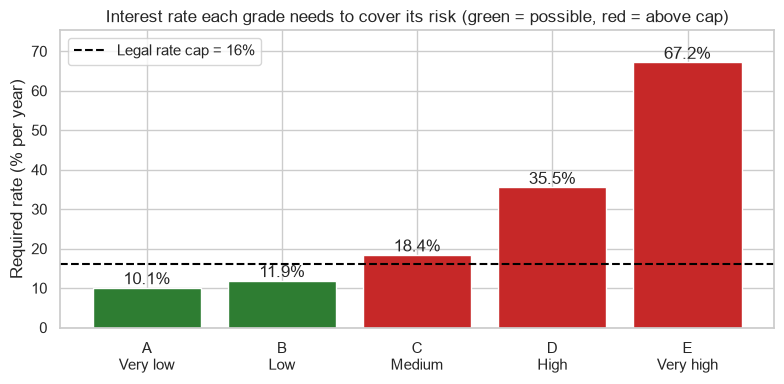

In [24]:
cap_pct = 100 * ASSUMPTIONS["rate_cap"]
fig, ax = plt.subplots(figsize=(8, 4))
colors = np.where(tariff["required_rate_pct"] <= cap_pct, "#2E7D32", "#C62828")
bars = ax.bar(tariff["grade"] + "\n" + tariff["label"], tariff["required_rate_pct"], color=colors)
ax.bar_label(bars, fmt="%.1f%%")
ax.axhline(cap_pct, color="black", ls="--", label=f"Legal rate cap = {cap_pct:.0f}%")
ax.set(title="Interest rate each grade needs to cover its risk (green = possible, red = above cap)",
       ylabel="Required rate (% per year)")
ax.margins(y=0.12)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "13_required_rate_vs_cap.png", dpi=150)
plt.show()

**How to read:** each bar is the interest rate a grade would need to cover its costs, expected loss and profit target. The dashed line is the legal cap (16%). Green = the bank can charge it. Red = it is above the cap.
**Look for:** C is just above the cap (18.4%), but D (35.5%) and E (67.2%) are far above it. No legal price can make them profitable.

**วิธีอ่าน:** แต่ละแท่งคือดอกเบี้ยที่เกรดนั้นต้องเก็บ เพื่อให้ครอบคลุมต้นทุน ความเสียหายที่คาด และกำไรเป้าหมาย เส้นประคือเพดานตามกฎหมาย (16%) สีเขียว = เก็บได้ สีแดง = เกินเพดาน
**สังเกต:** เกรด C เกินเพดานเล็กน้อย (18.4%) แต่ D (35.5%) และ E (67.2%) เกินไปมาก ไม่มีอัตราดอกเบี้ยที่ถูกกฎหมายใดทำให้ได้กำไร

## 5. Simple balance rules for staff / เกณฑ์ยอดหนี้แบบง่ายสำหรับพนักงาน

**EN:** the model only needs two facts: balance and student status. So each grade can be turned into a simple rule: *"a non-student with a balance above X is grade D"*. No computer needed at the front desk.

**TH:** โมเดลใช้ข้อมูลแค่ 2 อย่าง คือยอดหนี้และสถานะนักศึกษา เราจึงแปลงแต่ละเกรดเป็นกฎง่ายๆ ได้ เช่น *"คนที่ไม่ใช่นักศึกษา ยอดหนี้เกิน X อยู่เกรด D"* พนักงานใช้ได้ทันทีโดยไม่ต้องรันโมเดล

In [25]:
b = model.params


def balance_at(pd_level, is_student):
    """Balance at which the model's chance of default reaches pd_level."""
    logit = np.log(pd_level / (1 - pd_level))
    return (logit - b["Intercept"] - b["is_student"] * is_student) / b["balance"]


starts = {"B": 0.01, "C": 0.05, "D": 0.20, "E": 0.50}
rules = pd.DataFrame({
    "grade_starts_at": list(starts),
    "chance_of_default": [f"{p:.0%}" for p in starts.values()],
    "non_student_balance_above": [balance_at(p, 0) for p in starts.values()],
    "student_balance_above": [balance_at(p, 1) for p in starts.values()],
})
rules[["non_student_balance_above", "student_balance_above"]] = (
    rules[["non_student_balance_above", "student_balance_above"]].round(-1).astype(int)
)
rules

,grade_starts_at,chance_of_default,non_student_balance_above,student_balance_above
0,B,1%,1080,1190
1,C,5%,1360,1470
2,D,20%,1630,1740
3,E,50%,1870,1980


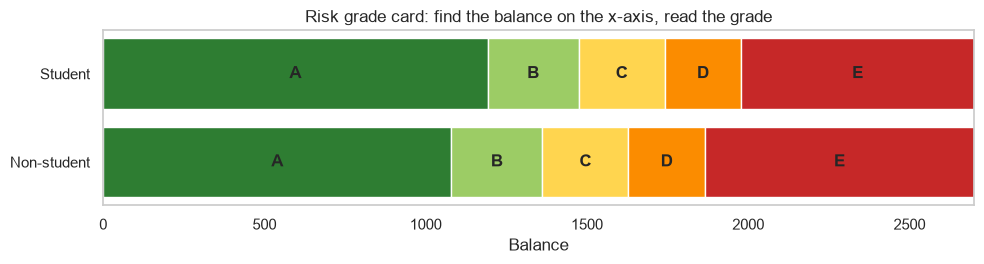

In [26]:
max_balance = 2700
fig, ax = plt.subplots(figsize=(10, 2.8))
for y, (group, is_student) in enumerate([("Non-student", 0), ("Student", 1)]):
    edges = [0] + [balance_at(p, is_student) for p in starts.values()] + [max_balance]
    for grade, left, right in zip(GRADE_COLORS, edges[:-1], edges[1:]):
        ax.barh(y, right - left, left=left, color=GRADE_COLORS[grade], edgecolor="white")
        ax.text((left + right) / 2, y, grade, ha="center", va="center", fontweight="bold")
ax.set_yticks([0, 1], ["Non-student", "Student"])
ax.set(xlim=(0, max_balance), xlabel="Balance",
       title="Risk grade card: find the balance on the x-axis, read the grade")
ax.grid(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "14_balance_grade_card.png", dpi=150)
plt.show()

**How to read:** find the customer's balance on the bottom axis, then read the colour in their row (student or non-student). Green = safe, red = very risky.
**Look for:**
- A non-student goes from grade **A to E between a balance of about 1,080 and 1,870**. Risk changes very fast in this narrow range.
- Students reach each grade about **110 later** (e.g. grade D starts at 1,740 for students vs 1,630 for others).

**วิธีอ่าน:** หายอดหนี้ของลูกค้าบนแกนล่าง แล้วดูสีในแถวของลูกค้า (นักศึกษา หรือไม่ใช่นักศึกษา) สีเขียว = ปลอดภัย สีแดง = เสี่ยงมาก
**สังเกต:**
- คนที่ไม่ใช่นักศึกษาเปลี่ยนจากเกรด **A เป็น E ในช่วงยอดหนี้ประมาณ 1,080 ถึง 1,870** ความเสี่ยงเปลี่ยนเร็วมากในช่วงแคบๆ นี้
- นักศึกษาจะถึงแต่ละเกรดช้ากว่าประมาณ **110** (เช่น เกรด D เริ่มที่ 1,740 สำหรับนักศึกษา และ 1,630 สำหรับคนทั่วไป)

## 6. Business recommendations / ข้อเสนอแนะทางธุรกิจ

**1. Focus on the riskiest 5% first / โฟกัสลูกค้าที่เสี่ยงที่สุด 5% ก่อน**
- **EN:** grades D–E are 5.3% of customers but hold **62 of 100 defaulters** and **72% of the expected loss**. Freeze their limits, send early payment reminders, and offer payment plans.
- **TH:** เกรด D–E มีลูกค้าแค่ 5.3% แต่มี **คนผิดนัด 62 จาก 100 คน** และเป็น **ความเสียหาย 72%** ควรระงับวงเงิน แจ้งเตือนก่อนครบกำหนดชำระ และเสนอแผนผ่อนชำระ

**2. Manage risky customers with limits, not price / คุมลูกค้าเสี่ยงด้วยวงเงิน ไม่ใช่ดอกเบี้ย**
- **EN:** from grade C up, the rate needed is above the 16% cap (D needs 35.5%, E needs 67.2%). A higher price cannot fix this, but lower exposure can: cutting D–E losses by **about 30%** makes the whole portfolio break even.
- **TH:** ตั้งแต่เกรด C ขึ้นไป ดอกเบี้ยที่ต้องเก็บเกินเพดาน 16% (D ต้อง 35.5%, E ต้อง 67.2%) การขึ้นดอกเบี้ยแก้ไม่ได้ แต่การลดวงเงินแก้ได้ ถ้าลดความเสียหายของ D–E ได้ **ประมาณ 30%** ทั้งพอร์ตจะเท่าทุน

**3. Reward the safest customers / ให้สิทธิพิเศษกับลูกค้าที่ปลอดภัยที่สุด**
- **EN:** grade A (72% of customers) has only a **0.2%** default rate. Offer lower rates (about 10%) or limit increases to keep them and grow their spending.
- **TH:** เกรด A (ลูกค้า 72%) ผิดนัดแค่ **0.2%** ควรเสนอดอกเบี้ยต่ำลง (ประมาณ 10%) หรือเพิ่มวงเงิน เพื่อรักษาลูกค้าและเพิ่มยอดใช้จ่าย

**4. Set a simple balance alert / ตั้งการแจ้งเตือนด้วยยอดหนี้**
- **EN:** alert staff when a non-student's balance passes **1,630** (students: **1,740**), where grade D starts. Watch the range from about **1,100 to 2,000** closely: risk goes from almost zero to very high inside it.
- **TH:** แจ้งเตือนพนักงานเมื่อยอดหนี้ของคนที่ไม่ใช่นักศึกษาเกิน **1,630** (นักศึกษา **1,740**) ซึ่งเป็นจุดเริ่มเกรด D และจับตาช่วงยอดหนี้ประมาณ **1,100 ถึง 2,000** อย่างใกล้ชิด เพราะความเสี่ยงเปลี่ยนจากเกือบศูนย์เป็นสูงมากในช่วงนี้

**5. Do not penalise students or rely on income / อย่าตัดสินว่านักศึกษาเสี่ยงกว่า และอย่าใช้รายได้อย่างเดียว**
- **EN:** at the same balance, students are **safer**. Judge risk by the model (balance + student status), not by the "student" label alone. Income did not help predict default in this data.
- **TH:** ที่ยอดหนี้เท่ากัน นักศึกษา **ปลอดภัยกว่า** ควรประเมินความเสี่ยงจากโมเดล (ยอดหนี้ + สถานะนักศึกษา) ไม่ใช่จากป้าย "นักศึกษา" อย่างเดียว และรายได้ไม่ได้ช่วยทำนายการผิดนัดในข้อมูลนี้

## 7. Limitations / ข้อจำกัด

- **EN:** money numbers depend on the **example assumptions** in Section 1. Replace them with the real bank's numbers before using this.
  **TH:** ตัวเลขเงินขึ้นกับ **สมมติฐานตัวอย่าง** ในหัวข้อ 1 ควรแทนด้วยตัวเลขจริงของธนาคารก่อนนำไปใช้
- **EN:** the data is **simulated** and has no time information, so the chance of default is treated as a 1-year chance.
  **TH:** ข้อมูลเป็น **ข้อมูลจำลอง** และไม่มีข้อมูลเวลา จึงถือว่าโอกาสผิดนัดเป็นโอกาสใน 1 ปี
- **EN:** results come from the 3,000 test customers. A real portfolio is larger, so read the **percentages**, not the totals.
  **TH:** ผลลัพธ์มาจากลูกค้าทดสอบ 3,000 คน พอร์ตจริงใหญ่กว่า จึงควรดู **สัดส่วน (%)** มากกว่ายอดรวม
- **EN:** the "what-if" loss cuts are scenarios, not measured results. Test each action on a small group of customers first.
  **TH:** การลดความเสียหายใน "what-if" เป็นสถานการณ์สมมติ ไม่ใช่ผลที่วัดได้จริง ควรทดลองแต่ละมาตรการกับลูกค้ากลุ่มเล็กก่อน